### Erika Fetyko & Ferdinand

## AstroSage

In [ ]:
## regular install
%pip install llama-cpp-python huggingface_hub

In [ ]:
## for mac with apple silicon
CMAKE_ARGS="-DCMAKE_OSX_ARCHITECTURES=arm64 -DLLAMA_METAL=on"
%pip install llama-cpp-python

In [ ]:
## for mac with apple silicon (continued)
%pip install huggingface_hub

In [ ]:
from llama_cpp import Llama
from huggingface_hub import hf_hub_download
import os
import sys
import contextlib

# Suppress warnings
@contextlib.contextmanager
def suppress_stderr():
    stderr = sys.stderr
    with open(os.devnull, 'w') as devnull:
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stderr = stderr

# or change the filename to AstroSage-8B-BF16.gguf for BF16 quantization
def download_model(repo_id="AstroMLab/AstroSage-8B-GGUF", filename="AstroSage-8B-Q8_0.gguf"):
    try:
        os.makedirs("models", exist_ok=True)
        local_path = os.path.join("models", filename)
        if not os.path.exists(local_path):
            print(f"Downloading {filename}...")
            with suppress_stderr():
                local_path = hf_hub_download(
                    repo_id=repo_id,
                    filename=filename,
                    local_dir="models",
                    local_dir_use_symlinks=False
                )
            print("Download complete!")
        return local_path
    except Exception as e:
        print(f"Error downloading model: {e}")
        raise

def initialize_llm():
    model_path = download_model()
    with suppress_stderr():
        return Llama(
            model_path=model_path,
            n_ctx=2048,
            n_threads=4
        )

def get_response(llm, prompt, max_tokens=128):
    response = llm(
        prompt,
        max_tokens=max_tokens,
        temperature=0.7,
        top_p=0.9,
        top_k=40,
        repeat_penalty=1.1,
        stop=["User:", "\n\n"]
    )
    return response['choices'][0]['text']


In [ ]:
llm = initialize_llm()

In [ ]:
# Example question about galaxy formation
first_question = "How does a galaxy form?"
print("\nQuestion:", first_question)
print("\nAI:", get_response(llm, first_question).strip(), "\n")

print("\nYou can now ask more questions! Type 'quit' or 'exit' to end the conversation.\n")

In [ ]:
## ask any question

while True:
    try:
        user_input = input("You: ")
        if user_input.lower() in ['quit', 'exit']:
            print("\nGoodbye!")
            break

        print("\nAI:", get_response(llm, user_input).strip(), "\n")

    except KeyboardInterrupt:
        print("\nGoodbye!")
        break
    except Exception as e:
        print(f"Error: {e}")

## AstroPT

In [ ]:
import torch
from astropt.model_utils import load_astropt
from astropt.local_datasets import GalaxyImageDataset

from datasets import load_dataset
from torch.utils.data import DataLoader
from torchvision import transforms

from itertools import islice
import datasets as ds_mod

import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

/opt/anaconda3/envs/aion-env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/anaconda3/envs/aion-env/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [ ]:
# Load AstroPT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = load_astropt(
    repo_id="smith42/astropt_v2.0",
    path="astropt/095M",
    weights_filename="ckpt.pt",
).to(device)
model.eval()

# Preprocessing function (from AstroPT huggingface)
def normalise(x):
    std, mean = torch.std_mean(x, dim=1, keepdim=True)
    return (x - mean) / (std + 1e-8)

def data_transforms():
    return transforms.Compose([transforms.Lambda(normalise)])

def _process_galaxy_wrapper(idx, func):
    """This function ensures that the image is tokenised in the same way as the pre-trained model is expecting"""
    galaxy = func(
        torch.from_numpy(np.array(idx["image"]).swapaxes(0, 2)).to(float)
    ).to(torch.float)
    galaxy_positions = torch.arange(0, len(galaxy), dtype=torch.long)
    return {
        "images": galaxy,
        "images_positions": galaxy_positions,
    }

galproc = GalaxyImageDataset(
    None,
    spiral=True,
    transform={"images": data_transforms()},
    modality_registry=model.modality_registry,
)

Using device: cpu
number of parameters: 95.18M
model loaded successfully from smith42/astropt_v2.0/astropt/095M
args: {'n_layer': 12, 'n_head': 12, 'n_embd': 768, 'n_chan': 3, 'block_size': 1024, 'dropout': 0.0, 'modalities': [ModalityConfig(name='images', input_size=768, pos_input_size=1, patch_size=16, embed_pos=True, loss_weight=1.0)], 'attn_type': 'causal'}


In [ ]:
# Stream a subset from the hugging face dataset
N = 2048

streaming_ds = load_dataset(
    "Smith42/galaxies",
    split="test",
    revision="v2.0",
    streaming=True,
)

processed_samples = []
raw_images = []
redshifts = []

# Subset of N images with valid spec_z (reduce process burden to CPU).
for sample in islice(streaming_ds, 20_000):
    z = sample["spec_z"]  

    # skip missing/NaN values
    if z is None or (isinstance(z, float) and np.isnan(z)):
        continue

    raw_images.append(sample["image"])  
    redshifts.append(z)

    processed = _process_galaxy_wrapper(sample, galproc.process_galaxy)
    processed_samples.append(processed)

    if len(processed_samples) >= N:
        break

print("Collected galaxies with valid spec_z:", len(processed_samples))

# Build HF Dataset and redshift array
ds = ds_mod.Dataset.from_list(processed_samples).with_format("torch")
redshifts = np.array(redshifts, dtype=np.float32)

print(ds)

Collected galaxies with valid spec_z: 2048
Dataset({
    features: ['images', 'images_positions'],
    num_rows: 2048
})
Redshift array shape: (2048,)


In [11]:
# DataLoader and AstroPT embeddings 

batch_size = 64
dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

all_emb = []

with torch.no_grad():
    for batch in dl:
        batch = {k: v.to(device) for k, v in batch.items()}
        emb = model.generate_embeddings(batch)["images"]  # (B, D)
        all_emb.append(emb.cpu().numpy())

emb_all = np.vstack(all_emb)  # (N, D)

print("All embeddings shape:", emb_all.shape)
print("Embeddings N:", emb_all.shape[0], "Redshift N:", redshifts.shape[0])

All embeddings shape: (2048, 768)
Embeddings N: 2048 Redshift N: 2048


Random query index: 182 spec_z: 0.07039877


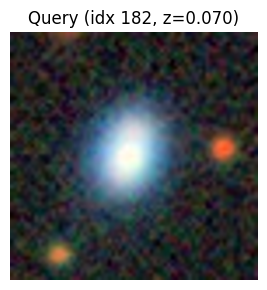

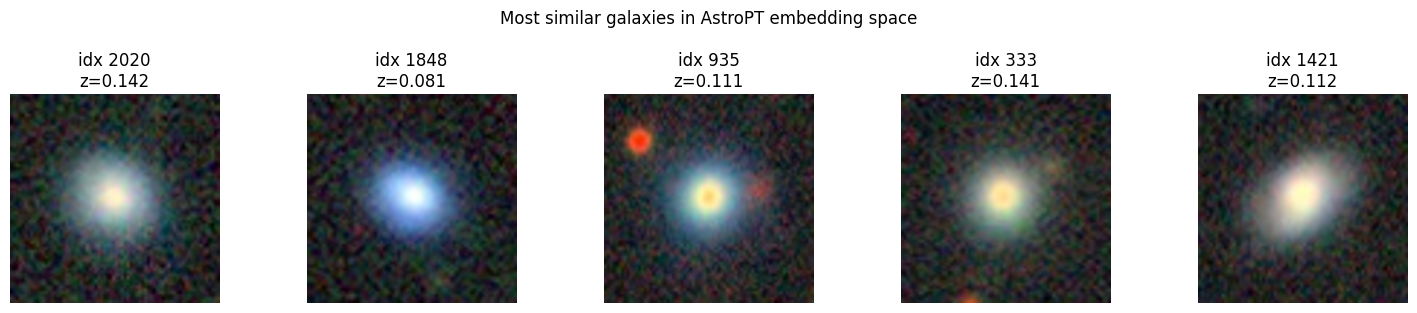

In [24]:
# Similarity search in AstroPT embedding space
# Code helped by ChatGPT

neighbors = 6  # 1 query + 5 similar galaxies

nn_sim = NearestNeighbors(
    n_neighbors=neighbors,
    metric="cosine",
)
nn_sim.fit(emb_all)

# Pick a random galaxy as query
rng = np.random.default_rng(42) 
query_idx = int(rng.integers(0, emb_all.shape[0]))
print("Random query index:", query_idx, "spec_z:", redshifts[query_idx])

# Find nearest neighbors (including the query itself at distance ~0)
distances, indices = nn_sim.kneighbors(
    emb_all[query_idx:query_idx+1],
    return_distance=True
)
indices = indices[0]
distances = distances[0]

# Plot query + similar galaxies

# Show query alone
plt.figure(figsize=(3, 3))
plt.imshow(raw_images[query_idx])
plt.axis("off")
plt.title(f"Query (idx {query_idx}, z={redshifts[query_idx]:.3f})")
plt.tight_layout()
plt.show()

# Now show the top 5 similar galaxies (excluding the query itself)
num_similar_to_show = min(5, len(indices) - 1)
similar_indices = indices[1:1 + num_similar_to_show]

fig, axes = plt.subplots(1, num_similar_to_show, figsize=(3 * num_similar_to_show, 3))

if num_similar_to_show == 1:
    axes = [axes]

for ax, idx in zip(axes, similar_indices):
    img = raw_images[idx]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"idx {idx}\nz={redshifts[idx]:.3f}")

plt.suptitle("Most similar galaxies in AstroPT embedding space", y=1.03)
plt.tight_layout()
plt.show()

k-NN redshift R²: 0.4228821823507414


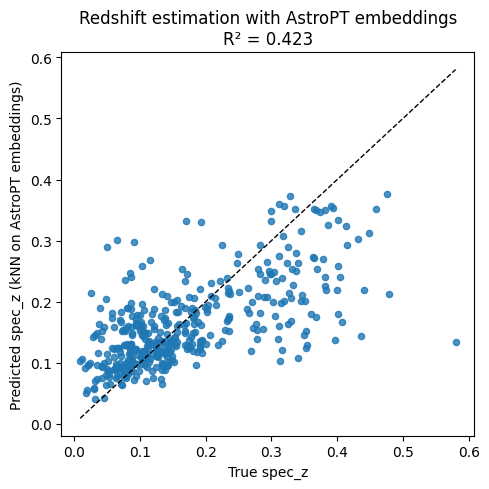

In [ ]:
# # ----------------------
# # k-NN redshift regression in AstroPT embedding space
# # ----------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     emb_all, redshifts, test_size=0.2, random_state=42
# )

# knn_reg = KNeighborsRegressor(
#     n_neighbors=10,
#     weights="distance",  # closer neighbors weigh more
# )

# knn_reg.fit(X_train, y_train)
# y_pred = knn_reg.predict(X_test)

# r2 = r2_score(y_test, y_pred)
# print("k-NN redshift R²:", r2)

# # True vs predicted redshift plot
# plt.figure(figsize=(5, 5))
# plt.scatter(y_test, y_pred, s=20, alpha=0.8)
# z_min = min(y_test.min(), y_pred.min())
# z_max = max(y_test.max(), y_pred.max())
# plt.plot([z_min, z_max], [z_min, z_max], "k--", lw=1)
# plt.xlabel("True spec_z")
# plt.ylabel("Predicted spec_z (kNN on AstroPT embeddings)")
# plt.title(f"Redshift estimation with AstroPT embeddings\nR² = {r2:.3f}")
# plt.tight_layout()
# plt.show()